# StandardCNN — Single Layer per Level (4 Conv) — Tiny ImageNet-200

Controlled **single-layer architecture experiment** using the supplied 4-Conv StandardCNN.

Training protocol is kept aligned with the current CNN experiments:
- same Tiny ImageNet 200 split: 450 train/class + 100 val/class
- same RandomCrop + HorizontalFlip + RandAugment(3,7) + Normalize training pipeline
- same batch size 64 and seed 42
- same SGD + Momentum + Nesterov
- same initial LR 0.05, cosine schedule to 1e-5
- same weight decay 1e-4
- same label smoothing 0.1
- same classifier dropout 0.5
- same fixed 100 epochs
- same clean-train evaluation every 5 epochs
- same best/latest checkpoint logic

**MixUp and CutMix are completely removed.** Every training batch uses the normal augmented training pipeline.

There is **no validation early stopping** and **no LR-threshold automatic stop**.

In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

from z_cnn.cnn_single_layer.model_single_layer import StandardCNN
from src.dataset._balance_class_subset import BalancedClassSubset
from src.dataset.tiny_imagenet_dataset_450train_100val import (
    TinyImageNetLoader,
    get_tiny_imagenet_class_names,
    means,
    stds,
    convert_to_rgb,
)
from src.utils import show_image

RESUME = False

SEED = 42
NUM_CLASSES = 200
TRAIN_PER_CLASS = 450
VAL_PER_CLASS = 100
BATCH_SIZE = 64
NUM_WORKERS = 4
EPOCHS = 100

INITIAL_LR = 0.05
MIN_LR = 1e-5
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.1
CLASSIFIER_DROPOUT = 0.5
CLEAN_EVAL_INTERVAL = 5

SAVE_DIR = Path(
    "./checkpoints_model_single_layer_no_mixup_cutmix/"
    "vgg_4conv_leakyrelu_flatten_fc"
)
SAVE_DIR.mkdir(parents=True, exist_ok=True)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Device:", DEVICE)
print("DataLoader workers:", NUM_WORKERS)
print("Epochs:", EPOCHS)
print("Batch-level MixUp/CutMix: DISABLED")

Device: mps
DataLoader workers: 4
Epochs: 100
Batch-level MixUp/CutMix: DISABLED


In [2]:
if DEVICE.type == "mps":
    print("Number of MPS devices:", torch.mps.device_count())

Number of MPS devices: 1


## 1. Dataset and exact class-balanced split

The split logic and image-level augmentation remain unchanged.  
"Normal training" still includes RandomCrop, HorizontalFlip, RandAugment(3,7), and normalization.

In [3]:
TINY_ROOT = Path("../../data/tiny_imagenet/tiny-imagenet-200-450train-100val")
SELECTED_CLASSES = list(range(NUM_CLASSES))

print("Dataset root:", TINY_ROOT)

train_tf = transforms.Compose([
    transforms.Lambda(convert_to_rgb),
    transforms.RandomCrop(64, padding=4, padding_mode="reflect"),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandAugment(num_ops=3, magnitude=7),
    transforms.ToTensor(),
    transforms.Normalize(mean=means, std=stds),
])

test_tf = transforms.Compose([
    transforms.Lambda(convert_to_rgb),
    transforms.ToTensor(),
    transforms.Normalize(mean=means, std=stds),
])

train_dataset, val_dataset, _, _ = TinyImageNetLoader(
    seed=SEED,
    root=TINY_ROOT,
    train_transform=train_tf,
    test_transform=test_tf,
).load()

clean_train_dataset, _, _, _ = TinyImageNetLoader(
    seed=SEED,
    root=TINY_ROOT,
    train_transform=test_tf,
    test_transform=test_tf,
).load()

if not hasattr(clean_train_dataset, "transform"):
    raise AttributeError("Expected the dataset to expose a transform attribute.")

train_subset = BalancedClassSubset(
    train_dataset, SELECTED_CLASSES, TRAIN_PER_CLASS, seed=SEED
)
clean_train_subset = BalancedClassSubset(
    clean_train_dataset, SELECTED_CLASSES, TRAIN_PER_CLASS, seed=SEED
)
val_subset = BalancedClassSubset(
    val_dataset, SELECTED_CLASSES, VAL_PER_CLASS, seed=SEED + 1
)

assert train_subset.samples == clean_train_subset.samples, (
    "Clean and augmented training subsets differ."
)
assert len(train_subset) == NUM_CLASSES * TRAIN_PER_CLASS
assert len(val_subset) == NUM_CLASSES * VAL_PER_CLASS

FULL_CLASS_NAMES = get_tiny_imagenet_class_names(train_dataset, TINY_ROOT)
CLASS_NAMES = [FULL_CLASS_NAMES[i] for i in SELECTED_CLASSES]

print("Train:", len(train_subset))
print("Validation:", len(val_subset))

Dataset root: ../../data/tiny_imagenet/tiny-imagenet-200-450train-100val
Tiny ImageNet loaded
Classes: 200
Train images: 90000
Validation images: 20000
Test images: 10000
Tiny ImageNet loaded
Classes: 200
Train images: 90000
Validation images: 20000
Test images: 10000
Train: 90000
Validation: 20000


## 2. DataLoaders

Same batch size and worker configuration as the other CNN experiments.

In [4]:
loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)

loader_options = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": DEVICE.type == "cuda",
    "persistent_workers": NUM_WORKERS > 0,
    **({"prefetch_factor": 2} if NUM_WORKERS > 0 else {}),
}

train_loader = DataLoader(
    train_subset,
    shuffle=True,
    generator=loader_generator,
    **loader_options,
)
val_loader = DataLoader(
    val_subset,
    shuffle=False,
    **loader_options,
)
clean_train_loader = DataLoader(
    clean_train_subset,
    shuffle=False,
    **loader_options,
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Training batches: 1407
Validation batches: 313


## Visual check

In [ ]:
NUM_SHOW = 5

train_iter = iter(train_loader)
clean_train_iter = iter(clean_train_loader)
val_iter = iter(val_loader)

train_images, train_labels = next(train_iter)
clean_train_images, clean_train_labels = next(clean_train_iter)
val_images, val_labels_batch = next(val_iter)

show_image(
    train_images, train_labels, NUM_SHOW, CLASS_NAMES,
    name="Train Images", has_norm=True
)
show_image(
    clean_train_images, clean_train_labels, NUM_SHOW, CLASS_NAMES,
    name="Clean Train Images", has_norm=True
)
show_image(
    val_images, val_labels_batch, NUM_SHOW, CLASS_NAMES,
    name="Validation Images", has_norm=True
)

## 3. Model, optimizer and cosine scheduler

The model is the supplied single-layer-per-level StandardCNN.  
No MixUp/CutMix logic exists in the optimizer or training loop.

In [5]:
base_model = StandardCNN(
    num_classes=NUM_CLASSES,
    classifier_dropout=CLASSIFIER_DROPOUT,
)

print("Parameters:", sum(p.numel() for p in base_model.parameters()))
print(
    "Trainable parameters:",
    sum(p.numel() for p in base_model.parameters() if p.requires_grad),
)

model = base_model.to(DEVICE)

def raw_model():
    return model

criterion = nn.CrossEntropyLoss(
    label_smoothing=LABEL_SMOOTHING
)

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=INITIAL_LR,
    momentum=0.9,
    weight_decay=WEIGHT_DECAY,
    nesterov=True,
)

TOTAL_STEPS = EPOCHS * len(train_loader)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=TOTAL_STEPS,
    eta_min=MIN_LR,
)

Parameters: 5931016
Trainable parameters: 5931016


## 4. Best and latest checkpoints

`best_model.pth` stores the highest validation-accuracy checkpoint.  
`latest_checkpoint.pth` stores the complete resumable training state.

In [6]:
BEST_PATH = SAVE_DIR / "best_model.pth"
LATEST_PATH = SAVE_DIR / "latest_checkpoint.pth"

history = {
    k: [] for k in [
        "epoch",
        "train_loss",
        "train_acc",
        "val_loss",
        "val_acc",
        "clean_train_loss",
        "clean_train_acc",
        "lr",
        "generalization_gap",
    ]
}

best_acc = -1.0
best_epoch = 0
start_epoch = 1

def rng_state():
    return dict(
        python=random.getstate(),
        numpy=np.random.get_state(),
        torch=torch.get_rng_state(),
        cuda=torch.cuda.get_rng_state_all()
        if torch.cuda.is_available() else None,
        loader=loader_generator.get_state(),
    )

def restore_rng(s):
    random.setstate(s["python"])
    np.random.set_state(s["numpy"])
    torch.set_rng_state(s["torch"])

    if torch.cuda.is_available() and s.get("cuda") is not None:
        torch.cuda.set_rng_state_all(s["cuda"])

    loader_generator.set_state(s["loader"])

def save_latest(epoch):
    payload = dict(
        epoch=epoch,
        model=raw_model().state_dict(),
        optimizer=optimizer.state_dict(),
        scheduler=scheduler.state_dict(),
        history=history,
        best_acc=best_acc,
        best_epoch=best_epoch,
        rng=rng_state(),
        config=dict(
            experiment="single_layer_4conv_no_mixup_cutmix",
            activation="leaky_relu_0.01",
            num_classes=NUM_CLASSES,
            batch_size=BATCH_SIZE,
            epochs=EPOCHS,
            train_per_class=TRAIN_PER_CLASS,
            val_per_class=VAL_PER_CLASS,
            classifier="flatten_fc_bn",
            classifier_dropout=CLASSIFIER_DROPOUT,
            augmentation="randaugment_3_7_no_batch_mixing",
            mixup=False,
            cutmix=False,
            initial_lr=INITIAL_LR,
            min_lr=MIN_LR,
            weight_decay=WEIGHT_DECAY,
            label_smoothing=LABEL_SMOOTHING,
        ),
    )

    temp = LATEST_PATH.with_suffix(".tmp")
    torch.save(payload, temp)
    os.replace(temp, LATEST_PATH)

if RESUME:
    ck = torch.load(
        LATEST_PATH,
        map_location="cpu",
        weights_only=False,
    )
    cfg = ck["config"]

    expected = {
        "experiment": "single_layer_4conv_no_mixup_cutmix",
        "activation": "leaky_relu_0.01",
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "classifier_dropout": CLASSIFIER_DROPOUT,
        "augmentation": "randaugment_3_7_no_batch_mixing",
        "mixup": False,
        "cutmix": False,
    }

    for key, expected_value in expected.items():
        if cfg.get(key) != expected_value:
            raise ValueError(
                f"Resume mismatch for {key}: "
                f"{cfg.get(key)} != {expected_value}"
            )

    raw_model().load_state_dict(ck["model"])
    optimizer.load_state_dict(ck["optimizer"])
    scheduler.load_state_dict(ck["scheduler"])

    for state in optimizer.state.values():
        for k, v in state.items():
            if torch.is_tensor(v):
                state[k] = v.to(DEVICE)

    history = ck["history"]
    best_acc = ck["best_acc"]
    best_epoch = ck["best_epoch"]
    start_epoch = ck["epoch"] + 1
    restore_rng(ck["rng"])

    print(
        f"Resuming from epoch {start_epoch} | "
        f"LR = {scheduler.get_last_lr()[0]:.10f}"
    )
else:
    print("Starting fresh single-layer 4Conv training from epoch 1.")

Starting fresh single-layer 4Conv training from epoch 1.


## 5. Standard augmented training — no MixUp, no CutMix

Every training batch follows exactly one path:

**RandomCrop + HorizontalFlip + RandAugment + Normalize → model → CrossEntropyLoss**

Training accuracy is therefore ordinary hard-label Top-1 accuracy.

In [7]:
def run_epoch(loader, training=False):
    if training:
        model.train()
    else:
        model.eval()

    total_loss = torch.zeros((), device=DEVICE)
    total_correct = torch.zeros((), device=DEVICE)
    total = 0

    context = torch.enable_grad() if training else torch.inference_mode()

    with context:
        for images, labels in tqdm(
            loader,
            leave=False,
            desc="Train" if training else "Eval",
        ):
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            if training:
                optimizer.zero_grad(set_to_none=True)

            logits = model(images)
            loss = criterion(logits, labels)

            predictions = logits.detach().argmax(dim=1)
            correct = (predictions == labels).sum()

            if training:
                loss.backward()
                optimizer.step()
                scheduler.step()

            batch_size = labels.size(0)
            total += batch_size
            total_loss += loss.detach() * batch_size
            total_correct += correct

    avg_loss = (total_loss / total).item()
    accuracy = (total_correct * (100.0 / total)).item()

    return avg_loss, accuracy

In [8]:
for epoch in tqdm(range(start_epoch, EPOCHS + 1)):
    train_loss, train_acc = run_epoch(
        train_loader,
        training=True,
    )

    if epoch == 1 or epoch % CLEAN_EVAL_INTERVAL == 0:
        clean_train_loss, clean_train_acc = run_epoch(
            clean_train_loader,
            training=False,
        )
    else:
        clean_train_loss, clean_train_acc = None, None

    val_loss, val_acc = run_epoch(
        val_loader,
        training=False,
    )

    current_lr = optimizer.param_groups[0]["lr"]

    epoch_metrics = {
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "clean_train_loss": clean_train_loss,
        "clean_train_acc": clean_train_acc,
        "lr": current_lr,
        "generalization_gap": (
            clean_train_acc - val_acc
            if clean_train_acc is not None else None
        ),
    }

    for name, value in epoch_metrics.items():
        history[name].append(value)

    if val_acc > best_acc:
        best_acc = val_acc
        best_epoch = epoch

        torch.save(
            {
                "model": raw_model().state_dict(),
                "epoch": epoch,
                "val_acc": val_acc,
                "class_names": CLASS_NAMES,
                "experiment": (
                    "Single-layer 4Conv LeakyReLU — "
                    "No MixUp/CutMix"
                ),
            },
            BEST_PATH,
        )

    save_latest(epoch)

    clean_text = (
        f"{clean_train_acc:.2f}% / {clean_train_loss:.4f}"
        if clean_train_acc is not None
        else "Skipped"
    )

    print(
        f"Epoch {epoch:03d}/{EPOCHS} | "
        f"Train: {train_acc:.2f}% / {train_loss:.4f} | "
        f"Val: {val_acc:.2f}% / {val_loss:.4f} | "
        f"Clean Train: {clean_text} | "
        f"LR: {current_lr:.7f} | "
        f"Best: {best_acc:.2f}% (epoch {best_epoch})"
    )

print(
    f"Training finished at epoch {EPOCHS}. "
    f"Best validation accuracy: {best_acc:.2f}% "
    f"(epoch {best_epoch})"
)

  0%|          | 0/100 [00:00<?, ?it/s]

Train:   0%|          | 0/1407 [00:06<?, ?it/s]

Eval:   0%|          | 0/1407 [00:06<?, ?it/s]

Eval:   0%|          | 0/313 [00:04<?, ?it/s]

Epoch 001/100 | Train: 4.85% / 4.8362 | Val: 10.43% / 4.3987 | Clean Train: 10.87% / 4.3765 | LR: 0.0499877 | Best: 10.43% (epoch 1)


...

Epoch 099/100 | Train: 56.80% / 2.4771 | Val: 55.11% / 2.5132 | Clean Train: Skipped | LR: 0.0000223 | Best: 55.25% (epoch 96)


Train:   0%|          | 0/1407 [00:00<?, ?it/s]

Eval:   0%|          | 0/1407 [00:00<?, ?it/s]

Eval:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 100/100 | Train: 56.82% / 2.4781 | Val: 55.22% / 2.5135 | Clean Train: 78.78% / 1.7258 | LR: 0.0000100 | Best: 55.25% (epoch 96)
Training finished at epoch 100. Best validation accuracy: 55.25% (epoch 96)


## 6. Full CNN diagnostics

In [ ]:
# from z_cnn_experiment.vgg_cnn.full_cnn_diagnostics import analyze_cnn_full
#
# diagnostic_model = StandardCNN(
#     num_classes=NUM_CLASSES,
#     classifier_dropout=CLASSIFIER_DROPOUT,
# )
#
# checkpoint = torch.load(
#     BEST_PATH,
#     map_location="cpu",
#     weights_only=False,
# )
# diagnostic_model.load_state_dict(checkpoint["model"])
#
# debug_val_loader = DataLoader(
#     val_subset,
#     batch_size=64,
#     shuffle=False,
#     num_workers=0,
# )
# debug_train_loader = DataLoader(
#     train_subset,
#     batch_size=64,
#     shuffle=True,
#     num_workers=0,
# )
#
# report = analyze_cnn_full(
#     model=diagnostic_model,
#     val_loader=debug_val_loader,
#     train_loader=debug_train_loader,
#     device=DEVICE,
#     criterion=nn.CrossEntropyLoss(
#         label_smoothing=LABEL_SMOOTHING
#     ),
#     max_val_batches=None,
#     max_grad_batches=3,
#     class_names=CLASS_NAMES,
#     output_dir=(
#         "full_cnn_diagnostics_"
#         "single_layer_no_mixup_cutmix"
#     ),
# )

> Note: if your current `full_cnn_diagnostics.py` only hooks `nn.ReLU`, its activation-statistics section will not capture `nn.LeakyReLU`. Other diagnostics can still run. The diagnostic hook can be extended later to include `nn.LeakyReLU`.

## 7. Curves and clean generalization gap

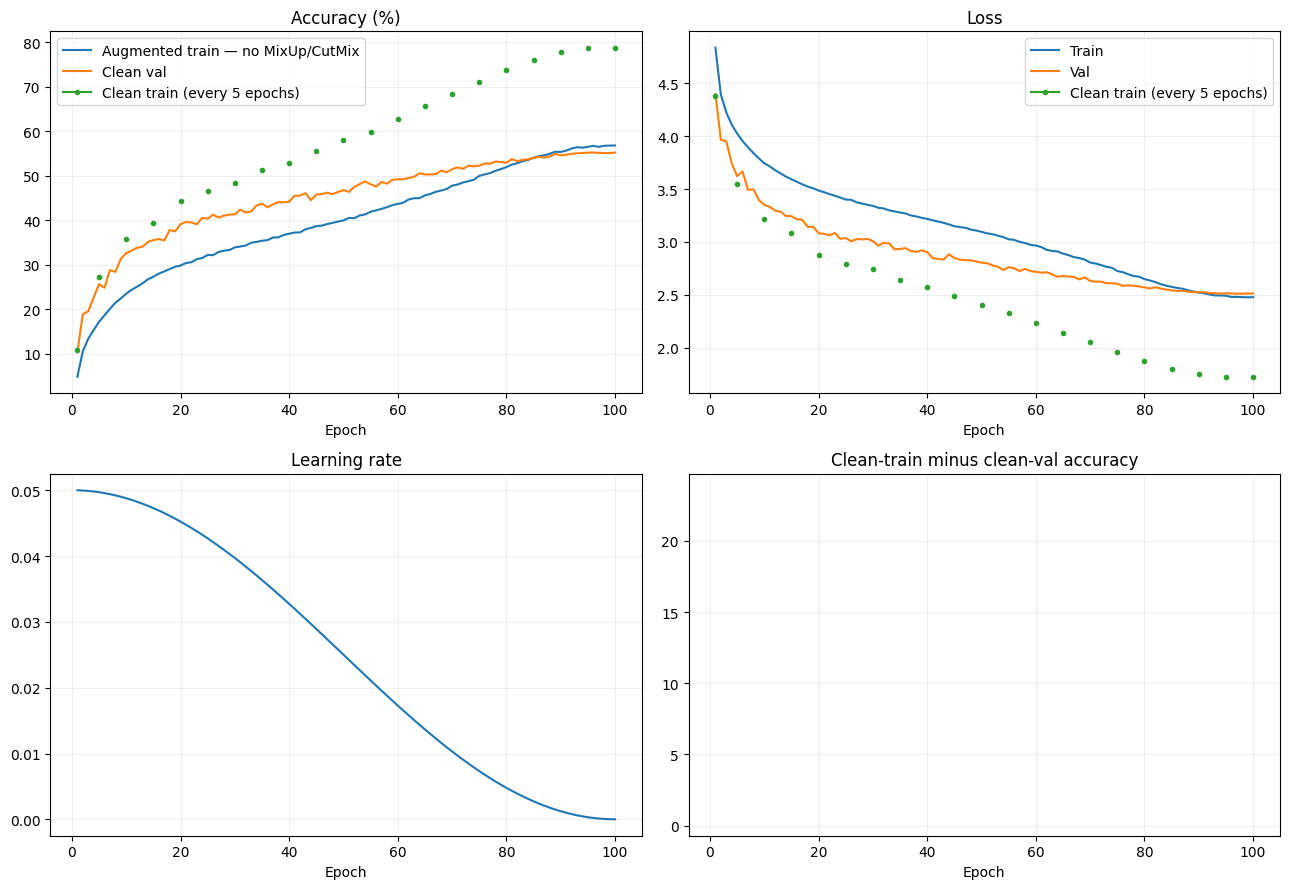

In [9]:
h = pd.DataFrame(history)

fig, axs = plt.subplots(2, 2, figsize=(13, 9))

axs[0, 0].plot(
    h.epoch, h.train_acc,
    label="Augmented train — no MixUp/CutMix"
)
axs[0, 0].plot(
    h.epoch, h.val_acc,
    label="Clean val"
)
axs[0, 0].plot(
    h.epoch, h.clean_train_acc,
    label="Clean train (every 5 epochs)",
    marker="o",
    markersize=3,
)
axs[0, 0].set_title("Accuracy (%)")
axs[0, 0].legend()

axs[0, 1].plot(h.epoch, h.train_loss, label="Train")
axs[0, 1].plot(h.epoch, h.val_loss, label="Val")
axs[0, 1].plot(
    h.epoch, h.clean_train_loss,
    label="Clean train (every 5 epochs)",
    marker="o",
    markersize=3,
)
axs[0, 1].set_title("Loss")
axs[0, 1].legend()

axs[1, 0].plot(h.epoch, h.lr)
axs[1, 0].set_title("Learning rate")

axs[1, 1].plot(h.epoch, h.generalization_gap)
axs[1, 1].set_title(
    "Clean-train minus clean-val accuracy"
)

for ax in axs.flat:
    ax.set_xlabel("Epoch")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [10]:
best = torch.load(
    BEST_PATH,
    map_location="cpu",
    weights_only=False,
)
raw_model().load_state_dict(best["model"])

clean_train_loss, clean_train_acc = run_epoch(
    clean_train_loader,
    training=False,
)
clean_val_loss, clean_val_acc = run_epoch(
    val_loader,
    training=False,
)

print(
    f"Best checkpoint: "
    f"clean train {clean_train_acc:.2f}%, "
    f"clean val {clean_val_acc:.2f}%, "
    f"gap {clean_train_acc - clean_val_acc:.2f} pp"
)

Eval:   0%|          | 0/1407 [00:00<?, ?it/s]

Eval:   0%|          | 0/313 [00:00<?, ?it/s]

Best checkpoint: clean train 78.67%, clean val 55.25%, gap 23.42 pp


## 8. Full validation features and class separation

Uses the model's 256-D FC representation returned by `return_features=True`.

In [11]:
@torch.no_grad()
def extract_features(loader):
    model.eval()

    ff = []
    yy = []

    for x, y in tqdm(loader, desc="Features"):
        _, f = model(
            x.to(DEVICE),
            return_features=True,
        )
        ff.append(f.cpu().numpy())
        yy.append(y.numpy())

    return np.concatenate(ff), np.concatenate(yy)

features, labels = extract_features(val_loader)

print("Feature shape:", features.shape)

centroids = np.stack([
    features[labels == i].mean(0)
    for i in range(NUM_CLASSES)
])

intra = np.mean([
    np.linalg.norm(
        features[labels == i] - centroids[i],
        axis=1,
    ).mean()
    for i in range(NUM_CLASSES)
])

from scipy.spatial.distance import pdist

inter = pdist(centroids).mean()

print(
    f"Mean intra-class distance to centroid: {intra:.4f} | "
    f"Mean inter-class centroid distance: {inter:.4f} | "
    f"Ratio: {inter / intra:.4f}"
)

np.savez_compressed(
    SAVE_DIR / "validation_features.npz",
    features=features,
    labels=labels,
    centroids=centroids,
)

Features:   0%|          | 0/313 [00:00<?, ?it/s]

Feature shape: (20000, 256)
Mean intra-class distance to centroid: 4.5615 | Mean inter-class centroid distance: 5.4499 | Ratio: 1.1947


## 9. 2D t-SNE — first 20 classes

Extracting 20-class features:   0%|          | 0/313 [00:00<?, ?it/s]

Feature shape: (2000, 256)
Feature dimension: 256
Label shape: (2000,)
Classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
Number of classes: 20
2D feature shape: (2000, 2)


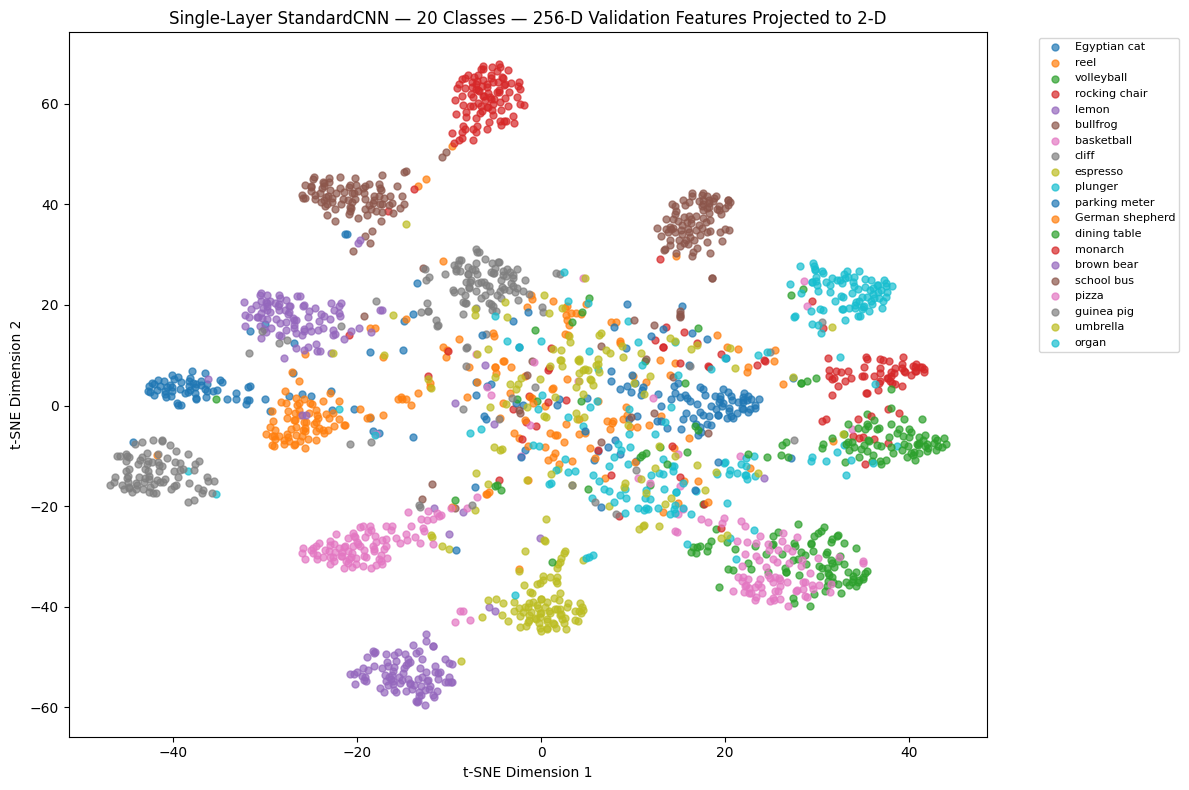

In [12]:
from sklearn.manifold import TSNE

NUM_TSNE_CLASSES = 20
TSNE_CLASS_IDS = list(range(NUM_TSNE_CLASSES))

tsne_val_loader = DataLoader(
    val_subset,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

@torch.inference_mode()
def extract_selected_features(
    model,
    data_loader,
    device,
    selected_class_ids,
):
    model.eval()

    all_features = []
    all_labels = []
    selected_class_ids = set(selected_class_ids)

    for images, labels in tqdm(
        data_loader,
        desc="Extracting 20-class features",
    ):
        mask = torch.tensor(
            [
                int(label) in selected_class_ids
                for label in labels
            ],
            dtype=torch.bool,
        )

        if not mask.any():
            continue

        images = images[mask].to(
            device,
            non_blocking=True,
        )
        selected_labels = labels[mask]

        _, selected_features = model(
            images,
            return_features=True,
        )

        all_features.append(
            selected_features.detach().cpu()
        )
        all_labels.append(
            selected_labels.cpu()
        )

    if not all_features:
        raise RuntimeError(
            "No samples found for selected t-SNE classes."
        )

    return (
        torch.cat(all_features, dim=0).numpy(),
        torch.cat(all_labels, dim=0).numpy(),
    )

tsne_features, tsne_labels = extract_selected_features(
    model=model,
    data_loader=tsne_val_loader,
    device=DEVICE,
    selected_class_ids=TSNE_CLASS_IDS,
)

FEATURE_DIM = tsne_features.shape[1]

print("Feature shape:", tsne_features.shape)
print("Feature dimension:", FEATURE_DIM)
print("Label shape:", tsne_labels.shape)
print("Classes:", np.unique(tsne_labels))
print("Number of classes:", len(np.unique(tsne_labels)))

tsne_2d = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    max_iter=1500,
    random_state=42,
)

features_2d = tsne_2d.fit_transform(tsne_features)

print("2D feature shape:", features_2d.shape)

plt.figure(figsize=(12, 8))

for class_id in TSNE_CLASS_IDS:
    mask = tsne_labels == class_id

    if not np.any(mask):
        continue

    plt.scatter(
        features_2d[mask, 0],
        features_2d[mask, 1],
        s=25,
        alpha=0.70,
        label=CLASS_NAMES[class_id],
    )

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title(
    f"Single-Layer StandardCNN — 20 Classes — "
    f"{FEATURE_DIM}-D Validation Features Projected to 2-D"
)
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=8,
)
plt.tight_layout()
plt.show()

## 10. Interactive 3D t-SNE — first 20 classes

In [ ]:
import plotly.express as px
from IPython.display import HTML, display

tsne_3d = TSNE(
    n_components=3,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    max_iter=1500,
    random_state=42,
)

features_3d = tsne_3d.fit_transform(
    tsne_features
)

print("3D feature shape:", features_3d.shape)

tsne_df = pd.DataFrame({
    "Dim1": features_3d[:, 0],
    "Dim2": features_3d[:, 1],
    "Dim3": features_3d[:, 2],
    "Class_ID": tsne_labels,
    "Class": [
        CLASS_NAMES[int(label)]
        for label in tsne_labels
    ],
})

fig = px.scatter_3d(
    tsne_df,
    x="Dim1",
    y="Dim2",
    z="Dim3",
    color="Class",
    hover_data={
        "Class_ID": True,
        "Class": True,
        "Dim1": False,
        "Dim2": False,
        "Dim3": False,
    },
    opacity=0.75,
    title=(
        f"Single-Layer StandardCNN — 20 Classes — "
        f"{FEATURE_DIM}-D Validation Features Projected to 3-D"
    ),
)

fig.update_traces(
    marker=dict(size=4)
)

fig.update_layout(
    width=950,
    height=700,
    scene=dict(
        xaxis_title="t-SNE Dimension 1",
        yaxis_title="t-SNE Dimension 2",
        zaxis_title="t-SNE Dimension 3",
    ),
    legend=dict(
        title="Class",
        font=dict(size=9),
    ),
)

display(
    HTML(
        fig.to_html(
            include_plotlyjs=True,
            full_html=False,
        )
    )
)